# Building an accessor - Met Office UKV data
In this tutorial we will demonstrate how to build a simple data accessor for pyearthtools, which is a key building block in a PyEarthTools pipeline. For this example we will use a small sample of Forecast Analysis data from the Met Office , which is available through AWS. Although one can 

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pathlib
import functools
import datetime

In [3]:
import matplotlib.pyplot
import cartopy
import numpy

In [4]:
import xarray

In [5]:
import h5py

### Exploring data
Let's start by looking at the data we are going to load.  A number of [Met Office Datasets](https://www.metoffice.gov.uk/services/data/external-data-channels) are available through third-party sources such as AWS and Snowflake. In this example we will look at loading some of UK high-resolution analysis data from AWS.

Links:
* [Met Office Data on Thiurd-party platforms](Links:https://www.metoffice.gov.uk/services/data/external-data-channels)
* [Met Office UKV data documentation](https://www.metoffice.gov.uk/api/assets/file/ukv-2km-ps47-asdi-pdf-updatespdf?prefix=assets)
* [UKV on AWS Sustainable Data Initiative](https://registry.opendata.aws/met-office-uk-deterministic/)
* [Contents of AWS S3 bucket for MO UKV data](https://met-office-atmospheric-model-data.s3.eu-west-2.amazonaws.com/index.html#uk-deterministic-2km/)

We'll need to specify some arguments to interact with the S3 bucket.

In [6]:
open_args = {
    'engine':"h5netcdf", #
    'storage_options': {"anon": True},
}

In [7]:
mf_args = {'concat_dim' : 'time',
           'combine' :'nested'
          }

Lets start by opening a sample of the data and visualising.

In [8]:
ukv_humidity_sample_ds = xarray.open_dataset(
    's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-relative_humidity_on_pressure_levels.nc',
    ** open_args,
)

In [9]:
ukv_humidity_sample_ds

<xarray.Dataset> Size: 167MB
Dimensions:                       (pressure: 33, projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * pressure                      (pressure) float32 132B 1e+05 ... 1e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 4kB -1.03...
  * projection_x_coordinate       (projection_x_coordinate) float32 4kB -1.15...
    forecast_period               timedelta64[ns] 8B ...
    forecast_reference_time       datetime64[ns] 8B ...
    time                          datetime64[ns] 8B ...
Dimensions without coordinates: bnds
Data variables:
    relative_humidity             (pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
    lambert_azimuthal_equal_area  int32 4B ...
    projection_y_coordinate_bnds  (projection_y_coordinate, bnds) float32 8kB ...
    projection_x_coordinate_bnds  (projection_x_coordinate, bnds) float32 8kB ...
    flag                          (pressure, projection_y_coordinate, projection_x_coordinate) int8 33MB ...
Attributes:
    ancillary_variables:          flag
    history:                      2026-06-01T13:20:41Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

In [10]:
ukv_humidity_sample_ds.pressure

<xarray.DataArray 'pressure' (pressure: 33)> Size: 132B
array([100000.,  97500.,  95000.,  92500.,  90000.,  85000.,  80000.,  75000.,
        70000.,  65000.,  60000.,  55000.,  50000.,  45000.,  40000.,  37500.,
        35000.,  32500.,  30000.,  27500.,  25000.,  22500.,  20000.,  17500.,
        15000.,  12500.,  10000.,   7000.,   5000.,   4000.,   3000.,   2000.,
         1000.], dtype=float32)
Coordinates:
  * pressure                 (pressure) float32 132B 1e+05 9.75e+04 ... 1e+03
    forecast_period          timedelta64[ns] 8B ...
    forecast_reference_time  datetime64[ns] 8B ...
    time                     datetime64[ns] 8B ...
Attributes:
    axis:       Z
    units:      Pa
    long_name:  pressure
    positive:   down

As the UK is at a high latitude, if we used a latitude / longtidue grid, it would be distored, so we use a different projection of the surface. We specify both the projection of the data and the projection we wanted to use for the visualisation.

In [11]:
data_projection = cartopy.crs.LambertAzimuthalEqualArea(central_latitude=54.9, central_longitude=-2.5, false_easting=0.0, false_northing=0.0)

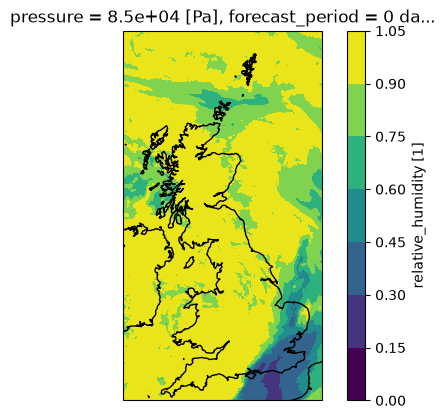

In [12]:
fig1 = matplotlib.pyplot.figure()
ax1 = fig1.add_subplot(1,1,1,projection=cartopy.crs.OSGB() )
ukv_humidity_sample_ds.sel({'pressure':85000})['relative_humidity'].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()

### Create a larger dataset from multiple files
When we interact with the data, we will likely want to use a larger sample, with more times and more varibales. The structure of the data is that each time and each variable is in it own file. So in order to build up a a dataset object with multiple variables and multiple times we have to build up a list of all the files, load them and merge them.

In [13]:
dt_list = [datetime.datetime(2026,6,1,0,0) + ix1 * datetime.timedelta(hours=12) for ix1 in range(20)]

In [14]:
var_list = [
    'temperature_on_pressure_levels',
    'relative_humidity_on_pressure_levels',
    'wind_speed_on_pressure_levels',
    'wind_direction_on_pressure_levels',
]

In [15]:
vt_template= '{dt.year:04d}{dt.month:02d}{dt.day:02d}T{dt.hour:02d}{dt.minute:02d}Z'

In [16]:
ukv_fname_template = '{vt_str}-PT0000H00M-{var_name}.nc'

In [17]:
ukv_path_dict = {current_var: [
    's3://met-office-atmospheric-model-data/uk-deterministic-2km/{vt_str}/{fname}'.format(
        vt_str=vt_template.format(dt=current_dt),
        fname=ukv_fname_template.format(vt_str=vt_template.format(dt=current_dt), var_name=current_var),
    )
    # for current_dt in dt_list for current_var in ['temperature_on_pressure_levels']
    for current_dt in dt_list 
] for current_var in var_list }

In [18]:
ukv_path_dict

{'temperature_on_pressure_levels': ['s3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T0000Z/20260601T0000Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260602T0000Z/20260602T0000Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260602T1200Z/20260602T1200Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260603T0000Z/20260603T0000Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260603T1200Z/20260603T1200Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260604T0000Z/20260604T0000Z-PT0000H00M-temperature_on_pressur

To create the dataset, we now load all times for each variable, then merge the variables into a single dataset.

In [19]:
ukv_sample_ds = xarray.merge([xarray.open_mfdataset(var_paths, ** (open_args | mf_args) ) 
                      for current_var,var_paths in  ukv_path_dict.items()])

In [20]:
ukv_sample_ds

<xarray.Dataset> Size: 11GB
Dimensions:                       (time: 20, pressure: 33,
                                   projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * time                          (time) datetime64[ns] 160B 2026-06-01 ... 2...
    forecast_reference_time       (time) datetime64[ns] 160B 2026-06-01 ... 2...
  * pressure                      (pressure) float32 132B 1e+05 ... 1e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 4kB -1.03...
  * projection_x_coordinate       (projection_x_coordinate) float32 4kB -1.15...
    forecast_period               timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: bnds
Data variables:
    air_temperature               (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 3GB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    lambert_azimuthal_equal_area  (time) int32 80B -2147483647 ... -2147483647
    projection_y_coordinate_bnds  (time, projection_y_coordinate, bnds) float32 155kB dask.array<chunksize=(1, 970, 2), meta=np.ndarray>
    projection_x_coordinate_bnds  (time, projection_x_coordinate, bnds) float32 167kB dask.array<chunksize=(1, 1042, 2), meta=np.ndarray>
    flag                          (time, pressure, projection_y_coordinate, projection_x_coordinate) int8 667MB dask.array<chunksize=(1, 17, 485, 521), meta=np.ndarray>
    relative_humidity             (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 3GB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    wind_speed                    (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 3GB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    wind_from_direction           (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 3GB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
Attributes:
    ancillary_variables:          flag
    history:                      2026-06-01T01:18:41Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

In [21]:
select_time = datetime.datetime(2026,6,7,12,0)

In [22]:
ukv_sample_ds.time

<xarray.DataArray 'time' (time: 20)> Size: 160B
array(['2026-06-01T00:00:00.000000000', '2026-06-01T12:00:00.000000000',
       '2026-06-02T00:00:00.000000000', '2026-06-02T12:00:00.000000000',
       '2026-06-03T00:00:00.000000000', '2026-06-03T12:00:00.000000000',
       '2026-06-04T00:00:00.000000000', '2026-06-04T12:00:00.000000000',
       '2026-06-05T00:00:00.000000000', '2026-06-05T12:00:00.000000000',
       '2026-06-06T00:00:00.000000000', '2026-06-06T12:00:00.000000000',
       '2026-06-07T00:00:00.000000000', '2026-06-07T12:00:00.000000000',
       '2026-06-08T00:00:00.000000000', '2026-06-08T12:00:00.000000000',
       '2026-06-09T00:00:00.000000000', '2026-06-09T12:00:00.000000000',
       '2026-06-10T00:00:00.000000000', '2026-06-10T12:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time                     (time) datetime64[ns] 160B 2026-06-01 ... 2026-0...
    forecast_reference_time  (time) datetime64[ns] 160B 2026-06-01 ... 2026-0...
    forecast_period          timedelta64[ns] 8B 00:00:00
Attributes:
    standard_name:  time

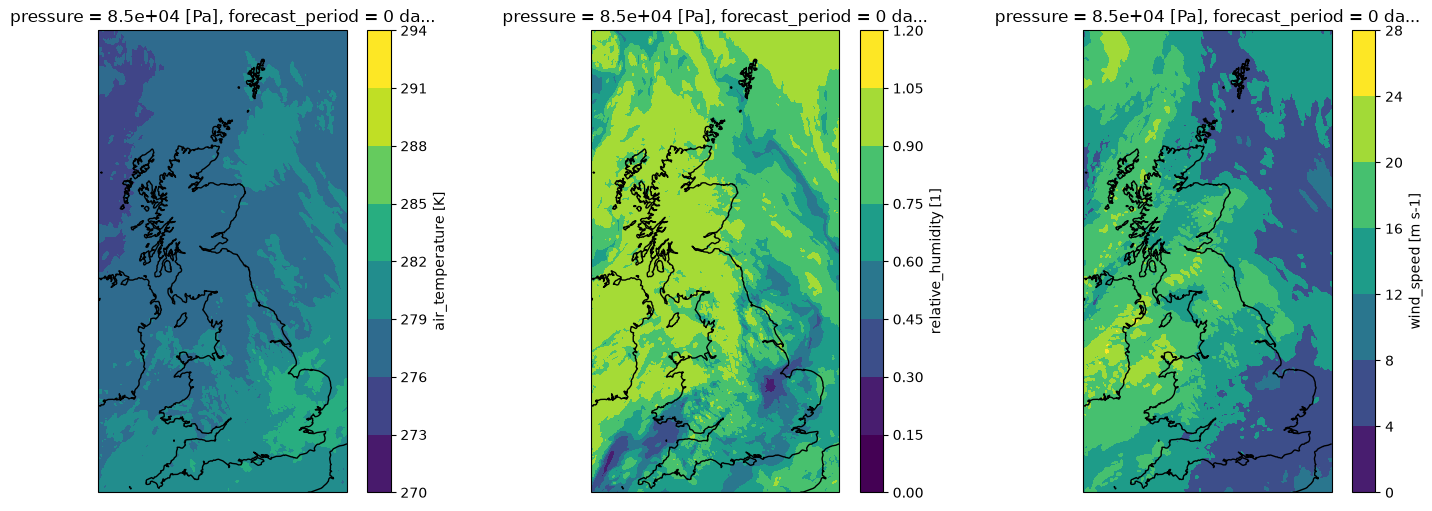

In [23]:
fig1 = matplotlib.pyplot.figure(figsize=(18,6))
# plot temperature at 850hpa pressure level
ax1 = fig1.add_subplot(1,3,1,projection=cartopy.crs.OSGB() )
ukv_sample_ds.sel({'pressure':85000, 'time': select_time})['air_temperature'].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()


ax1 = fig1.add_subplot(1,3,2,projection=cartopy.crs.OSGB() )

ukv_sample_ds.sel({'pressure':85000, 'time': select_time})['relative_humidity'].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()

ax1 = fig1.add_subplot(1,3,3,projection=cartopy.crs.OSGB() )
ukv_sample_ds.sel({'pressure':85000, 'time': select_time})['wind_speed'].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()


### Download the data

We will now use this dataset to save out the data locally. In future we could do this through a pyearthtools class, but for now we'll do it manually, so we can demonstrate different ways of building and using an accessor for this dataset.

We will save this data to a temporary directory for this example.

In [24]:
import tempfile

In [25]:
# change this path to a suitable local directory for which you have write permission
local_dir_obj = tempfile.TemporaryDirectory()
local_dir = pathlib.Path(local_dir_obj.name)
local_dir

PosixPath('/tmp/tmp7dokgx8k')

In [26]:
with tempfile.TemporaryDirectory()as td1:
    print(type(td1))

<class 'str'>


In [27]:
pathlib.Path(ukv_path_dict[var_list[0]][1]).suffix

'.nc'

In [28]:
ukv_path_dict

{'temperature_on_pressure_levels': ['s3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T0000Z/20260601T0000Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260601T1200Z/20260601T1200Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260602T0000Z/20260602T0000Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260602T1200Z/20260602T1200Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260603T0000Z/20260603T0000Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260603T1200Z/20260603T1200Z-PT0000H00M-temperature_on_pressure_levels.nc',
  's3://met-office-atmospheric-model-data/uk-deterministic-2km/20260604T0000Z/20260604T0000Z-PT0000H00M-temperature_on_pressur

In [29]:
local_path_dict = {}
for var_name, path_list in ukv_path_dict.items():
    local_path_dict[var_name] = []
    for path1 in path_list:
        print(var_name)
        out_path = local_dir / (pathlib.Path(path1).stem + pathlib.Path(path1).suffix)
        xarray.open_dataset(path1, **open_args).to_netcdf(out_path)
        local_path_dict[var_name]+= [local_dir / (pathlib.Path(path1).stem + pathlib.Path(path1).suffix)]

temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
temperature_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_humidity_on_pressure_levels
relative_h

In [30]:
[f1 for f1 in local_dir.iterdir()]

[PosixPath('/tmp/tmp7dokgx8k/20260610T1200Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260610T0000Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260609T1200Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260609T0000Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260608T1200Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260608T0000Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260607T1200Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260607T0000Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260606T1200Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260606T0000Z-PT0000H00M-wind_direction_on_pressure_levels.nc'),
 PosixPath('/tmp/tmp7dokgx8k/20260605T1200Z-PT0000

## Create a PyEarthTools Accessor
Now we will put the logic for loading the data into a PyEarthTools accessor class, so that the user doesn't need to know about the strcuture of the data on disk. To start with we will build an accessor for the netcdf files that we have downloaded. 

To create an accessor you need to implement the following:
* A class derived from the [Index](https://pyearthtools.readthedocs.io/en/latest/api/data/data_api.html#pyearthtools.data.indexes.Index)
* the `__init__` function to set up the object
* the `filesystem` function to supply a list of paths to load
* (optional) the `load` function if the loading of the data is non-standard. 

In [31]:
import pyearthtools

In [32]:
from pyearthtools.data import Petdt
from pyearthtools.data.indexes import ArchiveIndex
from pyearthtools.data.transforms import Transform, TransformCollection
from pyearthtools.data.archive import register_archive

In [33]:
class MO_UKV(ArchiveIndex):
    """
    PyEarthTools index for loading Met Office UKV data in Netcdf format.
    """
    MO_UKV_AWS_ROOT_PATH = 's3://met-office-atmospheric-model-data/uk-deterministic-2km/'
    MO_UKV_AWS_DIR_TEMPLATE = MO_UKV_AWS_ROOT_PATH + '{vt_str}'
    MO_UKV_FNAME_TEMPLATE = '{vt_str}-PT0000H00M-{var_name}.nc'
    
    def __init__(
        self,
        root_dir : pathlib.Path,
        variables: list[str] | str,
        *,
        transforms: Transform | TransformCollection | None = None,
    ):
        """
        Init function for Merra2 accessor base class.
        """
        self._root_dir = root_dir
        self._variables = variables
        super_transforms = TransformCollection([pyearthtools.data.transforms.variables.Trim(self._variables),]) + transforms
        
        # call the base class
        super().__init__(
            transforms=super_transforms,
        )
        self.record_initialisation()

    def filesystem(
        self,
        querytime: str | Petdt,
    ) -> pathlib.Path | dict[str, str | pathlib.Path]:
        

        querytime = Petdt(querytime)
        paths = []
        
        
        for var_name in self._variables:
            try:
                current_fname = MO_UKV.MO_UKV_FNAME_TEMPLATE.format(vt_str=vt_template.format(dt=querytime), var_name=var_name)
                if self._root_dir is None:
                    current_dir = MO_UKV.MO_UKV_AWS_DIR_TEMPLATE.format(vt_str=vt_template.format(dt=querytime))
                    current_path = f'{current_dir}/{current_fname}'
                else:
                    current_dir = self._root_dir
                    current_path = current_dir / current_fname
                
                paths += [ current_path ]
            except KeyError:
                print(f'Non data for var {var_name}')
        
        print(paths)
        return paths
        
        return ds
    def __desc__(self):
        return {
            "singleline": "Met Office UKV Forecast Analysis ",
            "range": "June 2026",
            "Documentation": "https://registry.opendata.aws/met-office-uk-deterministic/",
        }

    

Now we have created an accessor, we can select a set of variables and a time, and the user of rthe class doesn't need to know the details of the data storage.

In [34]:
ukv_accessor = MO_UKV(local_dir, var_list)

In [35]:
ukv_accessor['2026-06-01 12:00']

[PosixPath('/tmp/tmp7dokgx8k/20260601T1200Z-PT0000H00M-temperature_on_pressure_levels.nc'), PosixPath('/tmp/tmp7dokgx8k/20260601T1200Z-PT0000H00M-relative_humidity_on_pressure_levels.nc'), PosixPath('/tmp/tmp7dokgx8k/20260601T1200Z-PT0000H00M-wind_speed_on_pressure_levels.nc'), PosixPath('/tmp/tmp7dokgx8k/20260601T1200Z-PT0000H00M-wind_direction_on_pressure_levels.nc')]


<xarray.Dataset> Size: 567MB
Dimensions:                       (time: 1, pressure: 33,
                                   projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * time                          (time) datetime64[ns] 8B 2026-06-01T12:00:00
  * pressure                      (pressure) float32 132B 1e+05 ... 1e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 4kB -1.03...
  * projection_x_coordinate       (projection_x_coordinate) float32 4kB -1.15...
    forecast_period               timedelta64[ns] 8B ...
    forecast_reference_time       datetime64[ns] 8B ...
Dimensions without coordinates: bnds
Data variables:
    air_temperature               (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB dask.array<chunksize=(1, 33, 970, 1042), meta=np.ndarray>
    lambert_azimuthal_equal_area  (time) int32 4B -2147483647
    projection_y_coordinate_bnds  (time, projection_y_coordinate, bnds) float32 8kB dask.array<chunksize=(1, 970, 2), meta=np.ndarray>
    projection_x_coordinate_bnds  (time, projection_x_coordinate, bnds) float32 8kB dask.array<chunksize=(1, 1042, 2), meta=np.ndarray>
    flag                          (time, pressure, projection_y_coordinate, projection_x_coordinate) int8 33MB dask.array<chunksize=(1, 33, 970, 1042), meta=np.ndarray>
    relative_humidity             (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB dask.array<chunksize=(1, 33, 970, 1042), meta=np.ndarray>
    wind_speed                    (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB dask.array<chunksize=(1, 33, 970, 1042), meta=np.ndarray>
    wind_from_direction           (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB dask.array<chunksize=(1, 33, 970, 1042), meta=np.ndarray>
Attributes:
    ancillary_variables:          flag
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

### Creating an accessor for Zarr data
We could instead have saved the data in a format that optimised for object stores as found on cloud platforms, such as zarr. Different formats will give better performance on different platforms based on the specifics of the storage hardward and configuration, so although zarr is efficient in many cases, netcdf or another may be more appropriate in other cases.

In [36]:
zarr_dir = local_dir / 'zarr_data'
zarr_dir.mkdir()

We will start saving out the data a local zarr archive.

In [37]:
xarray.merge([xarray.open_mfdataset(var_paths, ** ( mf_args) ) 
                      for current_var,var_paths in  local_path_dict.items()]).to_zarr(zarr_dir)

Zarr archives are sufficiently standardised in their strcuture, that we don't need to implement out own index. Instead we can make use a a standard ZarrIndex provided by PyEarthTools. This could also be used for accessing remote data. See the [Remote_Zarr_loading.ipynb](Remote_Zarr_loading.ipynb) notebook for an example.

In [38]:
zarr_accessor = pyearthtools.data.archive.ZarrTimeIndex(
    zarr_dir,
    variables=var_list,
    remote=False,
)

In [39]:
zarr_accessor['2026-06-01 12:00']

<xarray.Dataset> Size: 567MB
Dimensions:                       (time: 1, pressure: 33,
                                   projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * time                          (time) datetime64[ns] 8B 2026-06-01T12:00:00
    forecast_reference_time       (time) datetime64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
  * pressure                      (pressure) float32 132B 1e+05 ... 1e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 4kB -1.03...
  * projection_x_coordinate       (projection_x_coordinate) float32 4kB -1.15...
    forecast_period               timedelta64[ns] 8B ...
Dimensions without coordinates: bnds
Data variables:
    air_temperature               (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    flag                          (time, pressure, projection_y_coordinate, projection_x_coordinate) int8 33MB dask.array<chunksize=(1, 17, 485, 521), meta=np.ndarray>
    lambert_azimuthal_equal_area  (time) int32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    projection_x_coordinate_bnds  (time, projection_x_coordinate, bnds) float32 8kB dask.array<chunksize=(1, 1042, 2), meta=np.ndarray>
    projection_y_coordinate_bnds  (time, projection_y_coordinate, bnds) float32 8kB dask.array<chunksize=(1, 970, 2), meta=np.ndarray>
    relative_humidity             (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    wind_from_direction           (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
    wind_speed                    (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB dask.array<chunksize=(1, 1, 128, 128), meta=np.ndarray>
Attributes:
    Conventions:                  CF-1.7, UKMO-1.0
    ancillary_variables:          flag
    history:                      2026-06-01T01:18:41Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8

## Building a remote accssor
PyEarthTools doesn't care where we the data is coming from. Since the data is being loaded through xarray, we can make use of the fact that xarray uses the [fsspec](https://filesystem-spec.readthedocs.io/en/latest/) library to load the data as we did at the start of this notebook from within our accessor. We need to add some extra functionality to our acessor though, because the default load function options won't work with the S3 bucket. We need to pass extra arguments, so we implement the `load` function so we can call the `open_dataset` function ourselves. What this really demonstrates is that we could be loading the data from any source, such as an API or other remote source. So long as the `load` function returns an xarray dataset, then the accessor can be abstracting away the loading of data from any source.

In [40]:
class MO_UKV_AWS(ArchiveIndex):
    """
    """
    MO_UKV_AWS_ROOT_PATH = 's3://met-office-atmospheric-model-data/uk-deterministic-2km/'
    MO_UKV_AWS_DIR_TEMPLATE = MO_UKV_AWS_ROOT_PATH + '{vt_str}'
    MO_UKV_FNAME_TEMPLATE = '{vt_str}-PT0000H00M-{var_name}.nc'
    
    def __init__(
        self,
        variables: list[str] | str,
        *,
        transforms: Transform | TransformCollection | None = None,
    ):
        """
        Init function for Merra2 accessor base class.
        """
        self._variables = variables
        super_transforms = TransformCollection([pyearthtools.data.transforms.variables.Trim(self._variables),]) + transforms
        
        # call the base class
        super().__init__(
            transforms=super_transforms,
        )
        self.record_initialisation()

    def filesystem(
        self,
        querytime: str | Petdt,
    ) -> pathlib.Path | dict[str, str | pathlib.Path]:
        

        querytime = Petdt(querytime)
        paths = []
        
        
        for var_name in self._variables:
            try:
                current_fname = MO_UKV.MO_UKV_FNAME_TEMPLATE.format(vt_str=vt_template.format(dt=querytime), var_name=var_name)
                current_dir = MO_UKV.MO_UKV_AWS_DIR_TEMPLATE.format(vt_str=vt_template.format(dt=querytime))
                current_path = f'{current_dir}/{current_fname}'
                paths += [ current_path ]
            except KeyError:
                print(f'No data for var {var_name}')
        
        print(paths)
        return paths

    def load(self, *args, **kwargs):
        ds = xarray.merge([xarray.open_dataset(path1, ** open_args ) for path1 in  args[0]])
        return ds
        
        return ds
    def __desc__(self):
        return {
            "singleline": "Met Office UKV Forecast Analysis ",
            "range": "June 2026",
            "Documentation": "https://registry.opendata.aws/met-office-uk-deterministic/",
        }

    

In [41]:
ukv_aws_accessor = MO_UKV_AWS(var_list)

In [43]:
sample_data = ukv_aws_accessor[datetime.datetime(2025,4,12,15,0)]

['s3://met-office-atmospheric-model-data/uk-deterministic-2km/20250412T1500Z/20250412T1500Z-PT0000H00M-temperature_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20250412T1500Z/20250412T1500Z-PT0000H00M-relative_humidity_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20250412T1500Z/20250412T1500Z-PT0000H00M-wind_speed_on_pressure_levels.nc', 's3://met-office-atmospheric-model-data/uk-deterministic-2km/20250412T1500Z/20250412T1500Z-PT0000H00M-wind_direction_on_pressure_levels.nc']


In [45]:
sample_data

<xarray.Dataset> Size: 567MB
Dimensions:                       (time: 1, pressure: 33,
                                   projection_y_coordinate: 970,
                                   projection_x_coordinate: 1042, bnds: 2)
Coordinates:
  * time                          (time) datetime64[ns] 8B 2025-04-12T15:00:00
  * pressure                      (pressure) float32 132B 1e+05 ... 1e+03
  * projection_y_coordinate       (projection_y_coordinate) float32 4kB -1.03...
  * projection_x_coordinate       (projection_x_coordinate) float32 4kB -1.15...
    flag                          (pressure, projection_y_coordinate, projection_x_coordinate) int8 33MB ...
    forecast_period               timedelta64[ns] 8B 00:00:00
    forecast_reference_time       datetime64[ns] 8B 2025-04-12T15:00:00
Dimensions without coordinates: bnds
Data variables:
    air_temperature               (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
    lambert_azimuthal_equal_area  (time) int32 4B -2147483647
    projection_y_coordinate_bnds  (time, projection_y_coordinate, bnds) float32 8kB ...
    projection_x_coordinate_bnds  (time, projection_x_coordinate, bnds) float32 8kB ...
    relative_humidity             (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
    wind_speed                    (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
    wind_from_direction           (time, pressure, projection_y_coordinate, projection_x_coordinate) float32 133MB ...
Attributes:
    history:                      2025-04-12T16:05:19Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT120H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.1
    Conventions:                  CF-1.7, UKMO-1.0

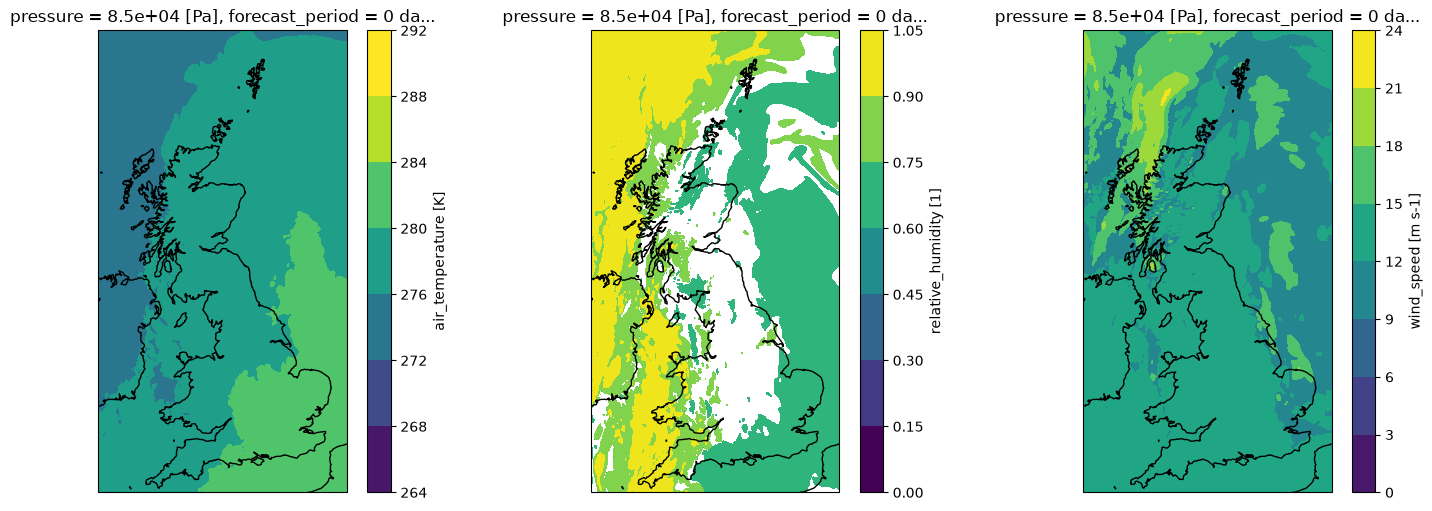

In [46]:
fig1 = matplotlib.pyplot.figure(figsize=(18,6))
# plot temperature at 850hpa pressure level
ax1 = fig1.add_subplot(1,3,1,projection=cartopy.crs.OSGB() )
sample_data.sel({'pressure':85000})['air_temperature'][0].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()


ax1 = fig1.add_subplot(1,3,2,projection=cartopy.crs.OSGB() )

sample_data.sel({'pressure':85000})['relative_humidity'][0].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()

ax1 = fig1.add_subplot(1,3,3,projection=cartopy.crs.OSGB() )
sample_data.sel({'pressure':85000})['wind_speed'][0].plot.contourf(
    ax=ax1,
    transform=data_projection,
)
ax1.coastlines()
